### AI-Powered Movie Recommendation System

A recommendation system built on the MovieLens dataset, combining
**content-based filtering** (genre similarity) and **collaborative
filtering** (user-rating similarity), enriched with metadata from the
TMDb API.

**Notebook structure:** Imports → Config → Load Data → EDA → Preprocessing
→ Feature Engineering → Modeling → Evaluation → Conclusions.


### Imports

Standard data analysis stack, plus `scipy` for the similarity/statistical
methods this assignment specifically calls for (`scipy.spatial.distance`,
`scipy.stats`), and `requests` for the TMDb API enrichment step.


In [66]:
import json
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from scipy import stats
from scipy.cluster.vq import kmeans, vq, whiten
from scipy.sparse import csr_matrix
from scipy.spatial.distance import cosine

### Config / Constants

Centralizing paths and constants here (rather than scattering literals
through the notebook) keeps the rest of the analysis readable and makes
it trivial to point at a different data location later.


In [2]:
RANDOM_STATE = 42  # reused anywhere sampling/ordering could vary, for reproducibility
DATA_DIR = Path("../data")
MOVIES_PATH = DATA_DIR / "movies.csv"
RATINGS_PATH = DATA_DIR / "ratings.csv"

# Consistent palette used across every chart
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)

### Load Data

Loading the two MovieLens CSVs. See the README for how to obtain these -
they're gitignored and expected directly under `data/`.


In [3]:
try:
    movies = pd.read_csv(MOVIES_PATH)
    ratings = pd.read_csv(RATINGS_PATH)
except FileNotFoundError as e:
    raise FileNotFoundError(
        "Expected movies.csv and ratings.csv directly under data/. "
        "See the README's 'Get the dataset' step."
    ) from e

print(f"movies: {movies.shape}")
print(f"ratings: {ratings.shape}")

movies: (62423, 3)
ratings: (25000095, 4)


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


### Inspect / EDA

Before touching the data, profile it: shape, dtypes, nulls, duplicates, and basic distributions. This surfaces data-quality issues up front rather than discovering them mid-pipeline.


In [6]:
for name, df in [("movies", movies), ("ratings", ratings)]:
    print(f"--- {name} ---")
    print(df.dtypes)
    print(f"Nulls:\n{df.isnull().sum()}")
    print(f"Duplicate rows: {df.duplicated().sum()}")

--- movies ---
movieId    int64
title        str
genres       str
dtype: object
Nulls:
movieId    0
title      0
genres     0
dtype: int64
Duplicate rows: 0
--- ratings ---
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object
Nulls:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Duplicate rows: 0


No nulls found in this dataset


In [7]:
ratings["rating"].describe()

count    2.500010e+07
mean     3.533854e+00
std      1.060744e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

### Rating Distribution

Ratings are bounded to 10 fixed values (0.5 - 5.0 in 0.5 steps), so a standard IQR outlier check doesn't apply. Every value in range is a valid rating by construction. Instead, we check the _shape_ of the distribution for rating inflation: `describe()` already showed a mean below 4.0 (3.54) but above the midpoint (3.0) of the scale, suggesting most users rate movies they liked rather than rating uniformly across the full range.


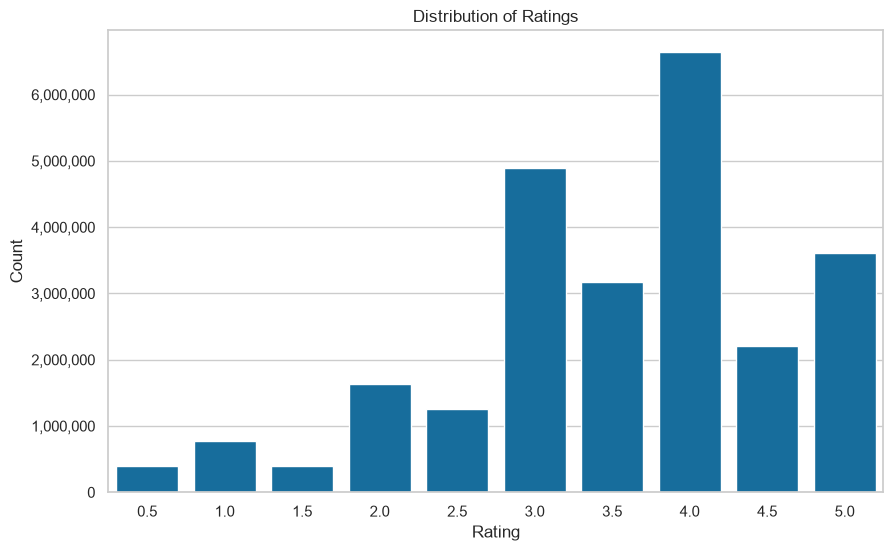

In [8]:
sns.countplot(x=ratings["rating"])
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y):,}"))
plt.show()

Ratings are heavily skewed towards the positive end:
4.0 is the most common rating (~6.5M out of total 25M which is ~26%), and ratings of 3.5 and above account for roughly 63% of all ratings. This is most likely 'rating inflation', which means that users are more likely to rate movies they actively liked than one they disliked or abandoned, so the observed distribution overrepresents positive experiences relative to true audience opinion. This matters for later modeling, where a raw average rating is a biased signal of movie quality, not just popularity.


In [9]:
movies["genres"].value_counts()

genres
Drama                                       9056
Comedy                                      5674
(no genres listed)                          5062
Documentary                                 4731
Comedy|Drama                                2386
                                            ... 
Animation|Children|Comedy|Fantasy|Horror       1
Comedy|Drama|Fantasy|War                       1
Children|Comedy|Fantasy|Mystery                1
Children|Comedy|Crime|Fantasy                  1
Comedy|Horror|Mystery|Sci-Fi|Western           1
Name: count, Length: 1639, dtype: int64

### Genre Distribution

`genres` has 0 nulls per `isnull()`, but a genre split reveals a hidden missing-value case:
5,062 of 62,423 movies have a "(no genres listed)" value instead of real genre data. Rather than filtering it silently, it is kept as its own bar below and labeled here explicitly, since dropping it would understate how much genre metadata is actually missing from this dataset.


In [10]:
genre_counts = movies["genres"].str.split("|").explode().value_counts()

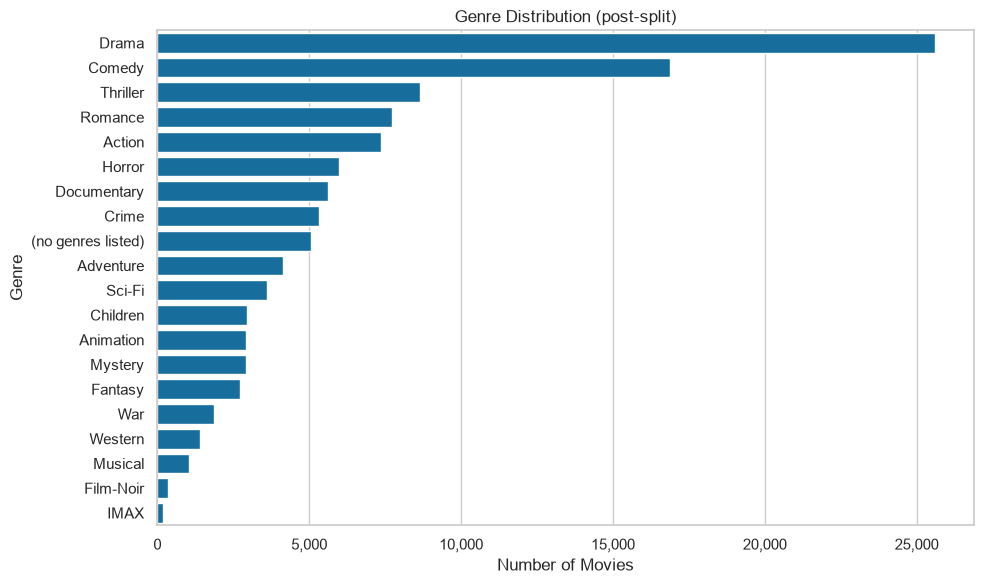

In [11]:
sns.barplot(x=genre_counts.values, y=genre_counts.index, orient="h")
plt.title("Genre Distribution (post-split)")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

Note: genres aren't mutually exclusive. A movie tagged `Horror|Thriller` counts towards both bars, so this chart shows how often each genre appears, not a partition of movies into single categories.


### Ratings per Movie / Ratings per User


In [12]:
ratings_per_movie = ratings.groupby("movieId").size()
ratings_per_user = ratings.groupby("userId").size()

In [13]:
ratings_per_movie.describe()

count    59047.000000
mean       423.393144
std       2477.885821
min          1.000000
25%          2.000000
50%          6.000000
75%         36.000000
max      81491.000000
dtype: float64

In [14]:
ratings_per_user.describe()

count    162541.000000
mean        153.807932
std         268.047590
min          20.000000
25%          36.000000
50%          71.000000
75%         162.000000
max       32202.000000
dtype: float64

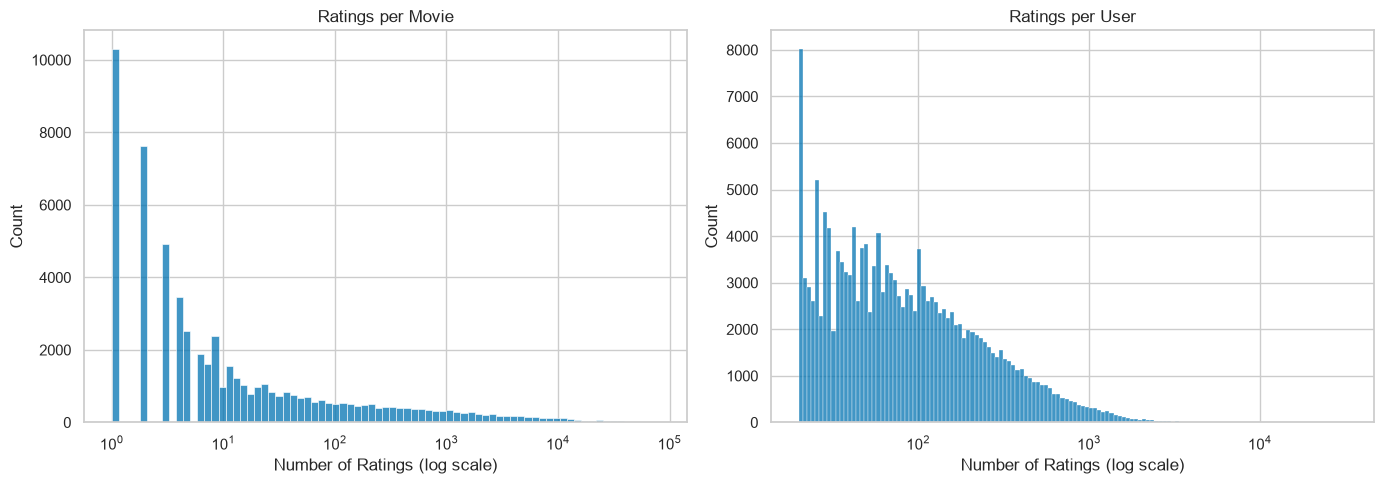

In [15]:
fix, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(ratings_per_movie, log_scale=True, ax=axes[0])
axes[0].set_title("Ratings per Movie")
axes[0].set_xlabel("Number of Ratings (log scale)")

sns.histplot(ratings_per_user, log_scale=True, ax=axes[1])
axes[1].set_title("Ratings per User")
axes[1].set_xlabel("Number of Ratings (log scale)")

plt.tight_layout()
plt.show()

Median ratings-per-movie is 6, but the mean is 423. A handful of blockbuster movies account for a disproportionate share of all ratings. Ratings-per-user has a similar mean / median gap (71 vs. 154), though it is bounded below at exactly 20. The MovieLens dataset is curated to only include users with > 20 ratings. Given the extreme skew, both are plotted on a log-scaled x-axis.


### User-Item Matrix Sparsity


In [16]:
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = len(ratings)

sparsity = 1 - (n_ratings / (n_users * n_movies))
print(f"Users: {n_users:,} | Movies: {n_movies:,} | Ratings: {n_ratings:,}")
print(f"Sparsity: {sparsity:.4%}")

Users: 162,541 | Movies: 59,047 | Ratings: 25,000,095
Sparsity: 99.7395%


A full user-item rating matrix would have ~9.6 billion cells (162,541 users x 59,047 movies), but only 25,000,095 are actually filled in. That's 99.74% empty. This matters for the recommendation engine because collaborative filtering works by comparing rating patterns between users (or movies) to find similarity (e.g 'users who rated this set of movies similarly to you also liked X'). That only works when there's enough overlap in what's actually been rated. At 99.74% empty, most pairs of users share almost no commonly-rated movies to compare, and most movies don't have enough raters to find a reliable pattern at all.


### Preprocessing: Timestamp to Datetime

Converting to a real datetime unlocks year / month-level grouping for any time-based analysis.


In [17]:
ratings["rated_at"] = pd.to_datetime(ratings["timestamp"], unit="s").dt.normalize()
ratings = ratings.drop(columns="timestamp")

In [18]:
ratings.head()

,userId,movieId,rating,rated_at
0,1,296,5.0,2006-05-17
1,1,306,3.5,2006-05-17
2,1,307,5.0,2006-05-17
3,1,665,5.0,2006-05-17
4,1,899,3.5,2006-05-17


### Rating Volume Over Time


In [19]:
ratings_per_year = ratings["rated_at"].dt.year.value_counts().sort_index()

In [20]:
ratings_per_year

rated_at
1995          3
1996    1430093
1997     626202
1998     272099
1999    1059080
2000    1735398
2001    1058750
2002     776654
2003     920295
2004    1048116
2005    1613550
2006    1038458
2007     931432
2008    1018001
2009     810127
2010     792436
2011     676498
2012     635208
2013     515684
2014     478270
2015    1604971
2016    1757440
2017    1689935
2018    1310761
2019    1200634
Name: count, dtype: int64

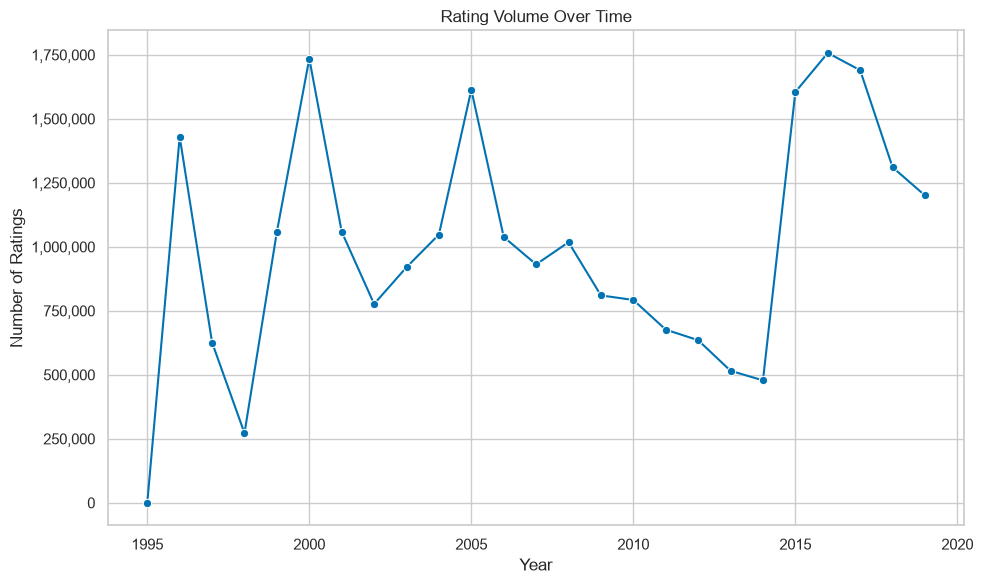

In [21]:
sns.lineplot(x=ratings_per_year.index, y=ratings_per_year.values, marker="o")
plt.title("Rating Volume Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y):,}"))
plt.tight_layout()
plt.show()

Rating volume isn't stable over the dataset's 25-year span. After the 1996 launch spike (1.43M ratings, likely inflated by initial platform seeding), volume declines steadily through a 2010-2014 trough, then rebounds sharply in 2015-2017.
This pattern is a reminder that 'more recent' ratings aren't uniformly more plentiful. Any time-aware modeling decision (e.g weighting recent ratings more heavily) should account for this volume swing rather than assuming a steady trend.


### Preprocessing: Release Year Extraction


In [25]:
def extract_release_year(titles: pd.Series) -> pd.Series:
    """
    Extract the trailing (YYYY) release year embedded in movie titles.

    Args:
        titles (pd.Series): Movie titles, most ending in "(YYYY)".

    Returns:
        pd.Series: Release year per title as nullable Int64. pd.NA where no trailing (YYYY) pattern is found.
    """
    years = titles.str.extract(r"\((\d{4})\)\s*$")[0]

    return years.astype("Int64")

In [26]:
movies["release_year"] = extract_release_year(movies["title"])

In [27]:
movies.head()

,movieId,title,genres,release_year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II (1995),Comedy,1995


### Genre One-Hot Matrix

Building a one-hot genre matrix for the content-based filtering step. Each column is a genre flag (1 if the movies has that genre, 0 otherwise).


In [ ]:
genre_matrix = movies["genres"].str.get_dummies(sep="|")
genre_matrix.index = movies["movieId"].values

`str.get_dummies(sep='|')` handles the pipe-delimited multi-label encoding in one vectorized call, setting multiple columns to 1 for movies with several genres (e.g `Horror|Thriller` gets both flags set). `(no genres listed)` comes through as its own column rather than being silently dropped, consistent with keeping it visible in the genre distribution chart.


In [38]:
genre_matrix.head()

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
1,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
5,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### User-Item Rating Matrix


In [39]:
user_codes, user_ids = pd.factorize(ratings["userId"], sort=True)
movie_codes, movie_ids = pd.factorize(ratings["movieId"], sort=True)

user_item_matrix = csr_matrix(
    (ratings["rating"], (user_codes, movie_codes)),
    shape=(len(user_ids), len(movie_ids)),
)

In [40]:
user_item_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 25000095 stored elements and shape (162541, 59047)>

Instead of building a 162,541 users x 59,047 movies matrix (as discussed in the EDA section), we build it using `scipy.sparse.csr_matrix`, which only stores the 25M actual ratings rather than the ~9.6 billion mostly-empty cells. `pd.factorize` maps the real userId / movieId values to compact 0-based row / column indices the spare matrix needs.


### Modeling

Build one feature vector per user (their average rating per genre). This needs `sum of ratings per genre` divided by `count of ratings per genre` per user. This can be done via two sparse matrix multiplications (`user_item_matrix @ genre`).

The `(no genres listed)` column is dropped here. It's a data-quality flag, not a real genre preference, so it shouldn't be treated as a clustering feature.


In [41]:
genre_cols = [c for c in genre_matrix.columns if c != "(no genres listed)"]
genre_aligned = genre_matrix.reindex(movie_ids)[genre_cols].values

rated_indicator = user_item_matrix.copy()
rated_indicator.data = np.ones_like(rated_indicator.data)

rating_sum_by_genre = user_item_matrix @ genre_aligned
rating_count_by_genre = rated_indicator @ genre_aligned

In [42]:
no_rating_pct_by_genre = pd.Series(
    (rating_count_by_genre == 0).mean(axis=0) * 100, index=genre_cols
)

no_rating_pct_by_genre.sort_values(ascending=False)

Documentary    62.844452
Film-Noir      58.257301
Western        32.302004
IMAX           26.780320
Musical        22.399272
Animation      13.729459
Horror         12.978879
War             9.619727
Children        8.705496
Mystery         6.356550
Fantasy         3.526495
Sci-Fi          1.524538
Crime           1.037277
Romance         0.906233
Adventure       0.442965
Thriller        0.364831
Action          0.348220
Comedy          0.098437
Drama           0.013535
dtype: float64

In [ ]:
overall_mean = np.asarray(user_item_matrix.sum(axis=1)).ravel() / np.diff(
    user_item_matrix.indptr
)

with np.errstate(invalid="ignore", divide="ignore"):
    avg_rating_by_genre = np.where(
        rating_count_by_genre > 0,
        rating_sum_by_genre / rating_count_by_genre,
        np.nan,
    )

nan_mask = np.isnan(avg_rating_by_genre)
user_genre_profile = np.where(nan_mask, overall_mean[:, None], avg_rating_by_genre)

Genre coverage per user varies widely. 62.84% of users have never rated a Documentary and 58.25% have never rated a Film-Noir, compared to Drama and Comedy where fewer than 0.1% of users have zero ratings. This confirms most users will have several genres with no rating signal at all, which the sum / count division would turn into `NaN`, which is handled by filling those with each user's own overall average rating instead.


In [ ]:
print(f"Shape: {user_genre_profile.shape}")
print(f"Any NaN remaining: {np.isnan(user_genre_profile).any()}")
print(
    f"Percentage of cells filled with overall_mean: {round(nan_mask.mean() * 100, 2)}%"
)

Shape: (162541, 19)
Any NaN remaining: False
Percentage of cells filled with overall_mean: 13.8%


No `NaN` remains after filling (shape `(162,541, 19)`), and 13.8% of all user-genre cells were filled with the user's overall average rating.


### K-Means: Row-Centering the Genre Profile

Before whitening, subtract each user's own average rating (across all genres) from their profile. Without this, a user who rates everything generously (e.g averaging 4.5 across every genre) and a user who rates everything harshly (averaging 2.5 across every genre) look far apart in distance regardless of genre taste. Their shared 'rating generosity' would dominate clustering over actual genre preference. Centering removes that shared level, leaving only each user's _relative_ genre preferences (do they rate Horror higher or lower than their own typical rating), which is what 'cluster by genre preference' should actually mean.


In [51]:
row_mean = user_genre_profile.mean(axis=1, keepdims=True)
user_genre_profile_centered = user_genre_profile - row_mean

In [46]:
before_std = pd.Series(user_genre_profile.std(axis=0), index=genre_cols)
before_std.sort_values()

Drama          0.493232
Comedy         0.558289
Thriller       0.567504
Crime          0.588371
Romance        0.599215
Action         0.599405
Adventure      0.605089
Film-Noir      0.661097
Sci-Fi         0.663642
Mystery        0.666595
Documentary    0.687114
Fantasy        0.694017
War            0.695188
IMAX           0.720075
Western        0.750816
Animation      0.765016
Children       0.780293
Musical        0.780857
Horror         0.813577
dtype: float64

### K-Means - User Genre Preference Profile

`scipy.cluster.vq.kmeans`'s own documentation requires whitened input:
"The features must be whitened first with the `whiten` function."
Even though every genre column is on the same 0.5 - 5.0 rating scale, their actual spread differs (Drama std = 0.493 vs. Horror std = 0.814). Without normalizing to unit variance, Horror would have disproportionate influence on the distance k-means uses to group users.


In [52]:
user_genre_profile_whitened = whiten(user_genre_profile_centered)

In [53]:
after_std = pd.Series(user_genre_profile_whitened.std(axis=0), index=genre_cols)
after_std.sort_values()

Sci-Fi         1.0
Adventure      1.0
Comedy         1.0
Western        1.0
Mystery        1.0
IMAX           1.0
Drama          1.0
Children       1.0
Horror         1.0
Fantasy        1.0
Thriller       1.0
Action         1.0
Crime          1.0
Animation      1.0
Documentary    1.0
Romance        1.0
War            1.0
Film-Noir      1.0
Musical        1.0
dtype: float64

### K-Means: Choosing k via the Elbow Method

Running `kmeans` across a range of k and comparing distortion (average distance from each user to their assigned cluster centroid) shows where adding more clusters stops meaningfully helping.

Note: This might take some time to run at this data size (162,541 users).


In [54]:
distortions = {}
for k in range(2, 11):
    _, distortion = kmeans(user_genre_profile_whitened, k, seed=RANDOM_STATE)
    distortions[k] = distortion

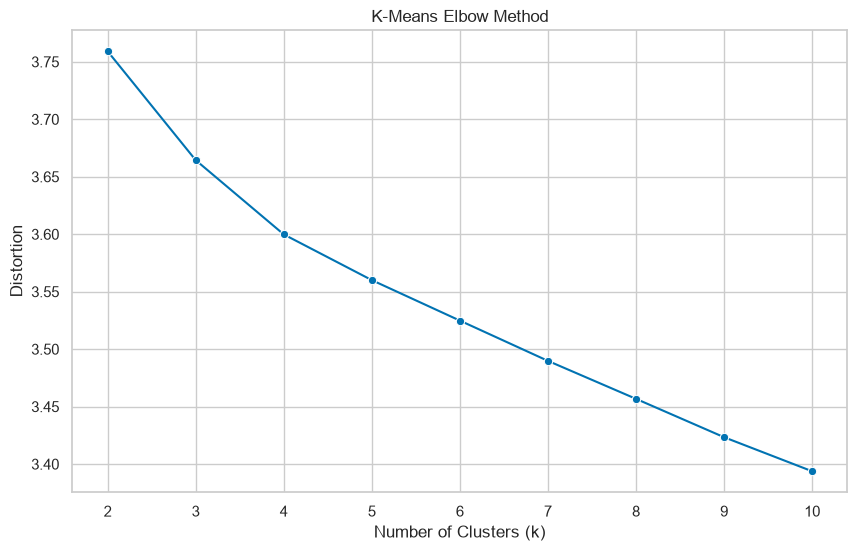

In [55]:
sns.lineplot(x=list(distortions.keys()), y=list(distortions.values()), marker="o")
plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Distortion")
plt.show()

Distortion decreases gradually (no sharp knee), but steep-to-flat transition lands at k = 5. This will be chosen at the elbow point.


### K-Means: Final Clustering (k = 5)


In [56]:
centroids, distortion = kmeans(user_genre_profile_whitened, 5, seed=RANDOM_STATE)
cluster_labels, _ = vq(user_genre_profile_whitened, centroids)

In [57]:
pd.Series(cluster_labels).value_counts().sort_index()

0    22745
1    38179
2    49916
3    40163
4    11538
Name: count, dtype: int64

Cluster sizes range from 11,358 to 49,916 users. The split isn't perfectly even, which is expected since genre preference isn't naturally balanced across the population.


In [60]:
centroid_std = user_genre_profile_centered.std(axis=0)
cluster_profiles = pd.DataFrame(centroids * centroid_std, columns=genre_cols)
cluster_profiles.round(2)

,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,-0.24,0.01,0.37,0.25,-0.02,-0.16,0.06,0.15,0.17,-0.06,-0.67,0.28,0.32,-0.32,0.18,-0.32,-0.38,0.35,0.04
1,0.10,0.05,-0.19,-0.34,-0.23,0.21,-0.05,0.13,-0.15,0.11,-0.11,0.15,-0.34,0.19,-0.14,0.08,0.14,0.30,0.08
2,-0.03,0.06,0.18,0.09,-0.07,0.02,-0.03,-0.03,0.08,-0.05,-0.08,0.05,0.09,0.02,-0.07,-0.00,-0.04,-0.06,-0.13
3,-0.34,-0.32,0.03,-0.13,-0.05,0.22,0.24,0.23,-0.15,0.33,-0.08,-0.20,0.04,0.23,0.08,-0.38,-0.02,0.28,0.02
4,0.13,-0.19,-1.07,-1.19,-0.06,0.52,0.23,0.43,-0.45,0.34,0.14,-0.00,-0.56,0.47,0.14,0.04,0.39,0.49,0.20


The five clusters represent genuinely different genre preferences, not just rating generosity:

- **Cluster 0** (22,745 users) - Rates Horror far below their own average (-0.67), also below on Thriller (-0.38) and Mystery (-0.32). Leans towards Animation (0.37), War (0.35) and Musical (0.32)
- **Cluster 1** (38,179 users) - Crime/War-leaning: avoids Children (-0.34) and Musical (-0.34). Favors War (0.30) and Crime (0.21).
- **Cluster 2** (49,916 users) - Generalist: no strong lean in either direction on any genre (largest cluster, all values near 0), i.e. users whose genre preferences track close to their own overall average across the board.
- **Cluster 3** (40,163 users) - Classic/serious-film fans: avoids blockbuster genres (Sci-Fi -0.38, Action -0.34, Adventure -0.32), favors Film-Noir (0.33), War (0.28), and Documentary (0.24).
- **Cluster 4** (11,538 users) - Strongly avoids family content: Children (-1.19) and Animation (-1.07) are far below average. The largest deviation of any cluster on any genre - while favoring Crime (0.52), War (0.49), and Drama (0.43). The smallest cluster, but the most distinct preference pattern.


### K-Means: Recommend Top-Rated Movies Within a User's Cluster

Map each user to their cluster, then for a target user, recommend the higher-rated movies among everyone in their cluster. A minimum rating-count threshold is required here. Without one, this repeats the same naive-averaging pitfall (a move with a single 5.0 rating outranks genuinely well-loved films). Movies the target user has already rated are excluded, since recommending something they've already seen isn't useful.


In [ ]:
user_cluster_map = pd.Series(cluster_labels, index=user_ids)
ratings["cluster"] = ratings["userId"].map(user_cluster_map)

In [ ]:
def recommend_for_user(
    user_id: int,
    ratings: pd.DataFrame,
    movies: pd.DataFrame,
    user_cluster_map: pd.Series,
    top_n: int = 10,
    min_ratings: int = 50,
) -> pd.DataFrame:
    """
    Recommend top-rated movies from a user's k-means cluster.

    Args:
        user_id (int): The target user's id.
        ratings (pd.DataFrame): Ratings data with a 'cluster' column already mapped from user_cluster_map.
        movies (pd.DataFrame): Movie metadata with movieId, title, genres.
        user_cluster_map (pd.Series): userId -> cluster label mapping.
        top_n (int, optional): Number of movies to recommend. Defaults to 10.
        min_ratings (int, optional): Minimum ratings within the cluster for a movie to be eligible. Defaults to 50.

    Returns:
        pd.DataFrame: Top-N movies by mean rating within the user's cluster, excluding movies already rated by the user.
    """
    cluster = user_cluster_map.loc[user_id]
    cluster_ratings = ratings[ratings["cluster"] == cluster]

    movie_stats = cluster_ratings.groupby("movieId")["rating"].agg(["mean", "count"])
    movie_stats = movie_stats[movie_stats["count"] >= min_ratings]

    already_rated = ratings.loc[ratings["userId"] == user_id, "movieId"]
    movie_stats = movie_stats.drop(index=already_rated, errors="ignore")

    top = movie_stats.sort_values("mean", ascending=False).head(top_n)

    return top.join(movies.set_index("movieId")[["title", "genres"]])

In [63]:
recommend_for_user(1, ratings, movies, user_cluster_map)

,mean,count,title,genres
movieId,,,,
159817,4.459633,545,Planet Earth (2006),Documentary
171011,4.434605,367,Planet Earth II (2016),Documentary
318,4.382436,24561,"Shawshank Redemption, The (1994)",Crime|Drama
170705,4.375283,441,Band of Brothers (2001),Action|Drama|War
172587,4.349057,53,Vacations in Prostokvashino (1980),Animation
163809,4.338863,211,Over the Garden Wall (2013),Adventure|Animation|Drama
170777,4.337209,129,There Once Was a Dog (1982),Animation|Children|Comedy
1196,4.331559,20200,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi
147250,4.330769,65,The Adventures of Sherlock Holmes and Doctor W...,(no genres listed)


### Hypothesis Testing: Do Horror and Film-Noir Ratings Differ?

- **H0 (Null-Hypothesis)**: Mean ratings for Horror and Film-Noir are equal.
- **H1**: Mean ratings for Horror and Film-Noir are different.

A movie can carry multiple genre tags, so a rating counts towards both groups if a movie is tagged both Horror and Film-Noir.


In [68]:
horror_ids = movies.loc[movies["genres"].str.contains("Horror"), "movieId"]
horror_ratings = ratings.loc[ratings["movieId"].isin(horror_ids), "rating"]

noir_ids = movies.loc[movies["genres"].str.contains("Film-Noir"), "movieId"]
noir_ratings = ratings.loc[ratings["movieId"].isin(noir_ids), "rating"]

print(f"Horror: mean = {horror_ratings.mean():.4f}, std = {horror_ratings.std():.4f}")
print(f"Film-Noir: mean = {noir_ratings.mean():.4f}, std = {noir_ratings.std():.4f}")

Horror: mean = 3.2936, std = 1.1408
Film-Noir: mean = 3.9257, std = 0.9144


In [ ]:
variance_ratio = max(horror_ratings.var(), noir_ratings.var()) / min(
    horror_ratings.var(), noir_ratings.var()
)

print(f"Variance ratio: {variance_ratio:.3f}")

Variance ratio: 1.556


A variance ratio of 1.556 (Horror's variance is larger) means the equal-variance assumption behind a standard independent t-test doesn't hold. We will use t-test instead since it doesn't assume equal variances.


In [ ]:
t_stat, p_value = stats.ttest_ind(noir_ratings, horror_ratings, equal_var=False)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

T-Statistic: 313.3470
P-value: 0.0000


The difference is statistically significant (p < 0.001). Film-Noir movies average 3.93 vs. Horror's 3.29, a gap of about 0.63 points on the 0.5 - 5.0 rating scale. That gap is large enough on a 4.5-point scale to represent a real, noticeable difference in how these two genres are typically rated.
